# Precision vs. Number of Triplets

In [ ]:
from project_consts import RESULTS_DIR
import json

dataset = "olivetti"
with open(RESULTS_DIR / 'stability10' / f'{dataset}_stability.json') as f:
    score_dist = json.load(f)
score_dist = {int(k): v for k, v in score_dist.items()}

,2n,4n,6n,8n,10n,12n,14n,16n,18n
0.01,0.036597,0.036838,0.036871,0.036885,0.036896,0.036901,0.036906,0.036910,0.036913
0.10,0.036752,0.036889,0.036909,0.036917,0.036923,0.036926,0.036928,0.036930,0.036931
0.25,0.036847,0.036920,0.036930,0.036935,0.036938,0.036939,0.036940,0.036942,0.036942
0.50,0.036953,0.036954,0.036954,0.036955,0.036955,0.036954,0.036954,0.036954,0.036954
0.75,0.037063,0.036989,0.036977,0.036975,0.036971,0.036970,0.036968,0.036967,0.036966
0.90,0.037160,0.037020,0.036999,0.036992,0.036987,0.036983,0.036981,0.036979,0.036977
0.99,0.037323,0.037072,0.037034,0.037023,0.037013,0.037007,0.037001,0.037000,0.036995


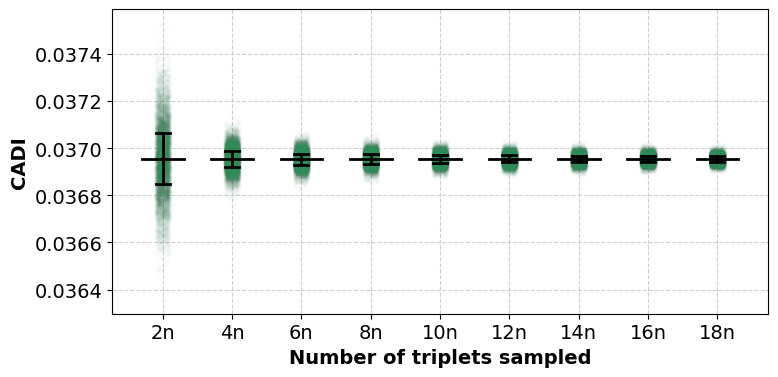

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# To DataFrame
df = pd.DataFrame([
    {"label": k, "value": v}
    for k, values in score_dist.items()
    for v in values
])

# Plot

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["font.size"] = 14
plt.rcParams["axes.labelweight"] = "bold"
fig, ax = plt.subplots(
    figsize=(8,4),
    # dpi=300
)
sns.stripplot(data=df, x="label", y="value",
               alpha=0.01, size=3, color='seagreen',
               edgecolor='seagreen',
               linewidth=0.,
               ax=ax
)

# quantile df
quantiles = dict()

for i, label in enumerate(df['label'].unique()):
    data_subset = df[df['label'] == label]['value']
    q1 = data_subset.quantile(0.25)
    q2 = data_subset.quantile(0.5)
    q3 = data_subset.quantile(0.75)
    
    # Draw vertical line for IQR
    ax.plot([i, i], [q1, q3], color='black', linewidth=2, zorder=10)
    
    # Horizontal lines for Q1, Q2, Q3
    ax.plot([i-0.1, i+0.1], [q1, q1], color='black', linewidth=2, zorder=10)
    ax.plot([i-0.3, i+0.3], [q2, q2], color='black', linewidth=2, zorder=10)
    ax.plot([i-0.1, i+0.1], [q3, q3], color='black', linewidth=2, zorder=10)

    # quantiles df
    quantiles[f"{2 * (int(i) + 1)}n"] = {q : data_subset.quantile(q) for q in [0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99]}


ax.grid(color="#cecece", linestyle='--')

ax.set_ylabel("CADI")

xticks = ax.get_xticks()
ax.set_xticks(xticks)
new_labels = [f"{2 * (int(tick) + 1)}n" for tick in xticks]
ax.set_xticklabels(new_labels)
ax.set_xlabel("Number of triplets sampled", fontsize=14)


ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=8))


plt.tight_layout()

# quantiles df
display(pd.DataFrame(quantiles))

plt.show()


### All

#### Line plot

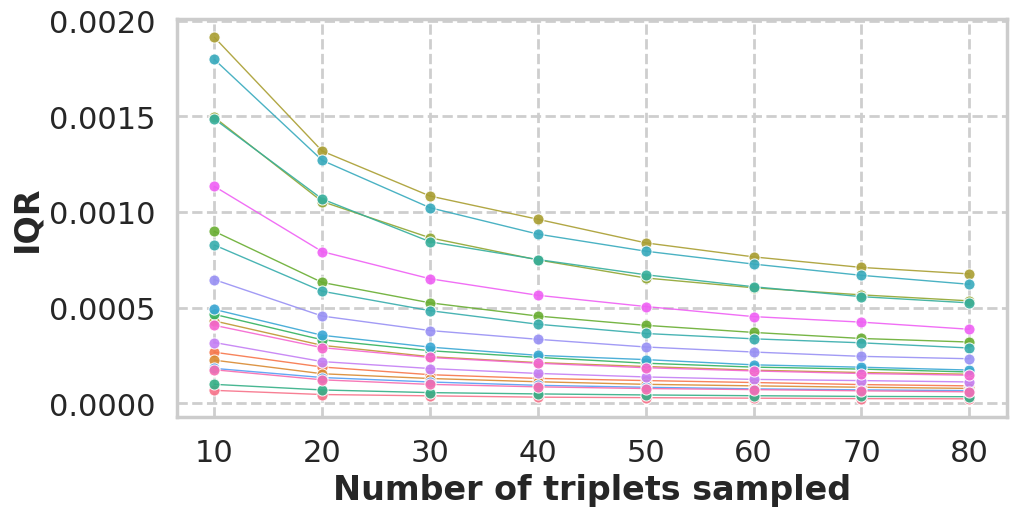

In [ ]:
from project_consts import RESULTS_DIR
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

STABILITY_DIR = RESULTS_DIR / 'stability10'

all_iqr_data = []

for stability_file in STABILITY_DIR.iterdir():
    dataset = stability_file.stem.split("_stability")[0]

    with open(stability_file) as f:
        score_dist = json.load(f)

    score_dist = {int(k): v for k, v in score_dist.items()}

    # Remove 1 if present
    score_dist.pop(1, None)

    # Compute IQR per k
    for k, values in score_dist.items():
        series = pd.Series(values)
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1

        all_iqr_data.append({X_surp
            "dataset": dataset,
            "k": k,
            "iqr": iqr
        })

# Create dataframe
df_all = pd.DataFrame(all_iqr_data)

# Sort by k to ensure proper line plotting
df_all = df_all.sort_values(["dataset", "k"])

k_vals = df_all['k'].unique()

# Plot
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["font.size"] = 1
plt.rcParams["axes.labelweight"] = "bold"

fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=df_all,
    x="k",
    y="iqr",
    hue="dataset",
    legend=False,      # No legend
    marker="o",
    linewidth=1,
    markersize=8,
    alpha=0.9,
    ax=ax
)

ax.set_xlabel("Number of triplets sampled")
ax.set_ylabel("IQR")
ax.grid(color="#cecece", linestyle='--')

ax.set_xticks(k_vals)
# ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=7))

plt.tight_layout()
plt.show()

#### Stripplots

In [ ]:
from project_consts import RESULTS_DIR, GENERAL_FIGS_DIR
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

STABILITY_DIR = RESULTS_DIR / 'stability10'
stability_fig_dir = GENERAL_FIGS_DIR / 'stability10'
stability_fig_dir.mkdir(parents=True, exist_ok=True)

for stability_file in STABILITY_DIR.iterdir():
    dataset = stability_file.stem.split("_stability")[0]
    with open(stability_file) as f:
        score_dist = json.load(f)
    score_dist = {int(k): v for k, v in score_dist.items()}

    # Remove 1
    if 1 in score_dist:
        del score_dist[1]


    # To DataFrame
    df = pd.DataFrame([
        {"label": k, "value": v}
        for k, values in score_dist.items()
        for v in values
    ])

    k_vals = list(score_dist.keys())

    # Plot

    plt.rcParams["font.family"] = "DejaVu Sans"
    plt.rcParams["font.size"] = 14
    plt.rcParams["axes.labelweight"] = "bold"
    
    fig, ax = plt.subplots(
        figsize=(8,4),
        # dpi=300
    )
    sns.stripplot(data=df, x="label", y="value",
                alpha=0.01, size=3, color='seagreen',
                edgecolor='seagreen',
                linewidth=0.,
                ax=ax
    )

    # quantile df
    val_range = dict()

    for i, label in enumerate(df['label'].unique()):
        data_subset = df[df['label'] == label]['value']
        q1 = data_subset.quantile(0.25)
        q2 = data_subset.quantile(0.5)
        q3 = data_subset.quantile(0.75)
        
        # Draw vertical line for IQR
        ax.plot([i, i], [q1, q3], color='black', linewidth=2, zorder=10)
        
        # Horizontal lines for Q1, Q2, Q3
        ax.plot([i-0.1, i+0.1], [q1, q1], color='black', linewidth=2, zorder=10)
        ax.plot([i-0.3, i+0.3], [q2, q2], color='black', linewidth=2, zorder=10)
        ax.plot([i-0.1, i+0.1], [q3, q3], color='black', linewidth=2, zorder=10)

        # quantiles df
        quantiles = {q : data_subset.quantile(q) for q in [0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99]}
        val_range[k_vals[i]] = {
            0.5 : quantiles[0.75] - quantiles[0.25],
            0.8 : quantiles[0.9] - quantiles[0.1],
            0.98 : quantiles[0.99] - quantiles[0.01]
        }


    ax.grid(color="#cecece", linestyle='--')

    ax.set_ylabel("CADI")

    # Set x-tick-labels to n, 2n, 4n etc
    xticks = ax.get_xticks()
    ax.set_xticks(xticks)
    ax.set_xticklabels(k_vals)
    ax.set_xlabel("Number of triplets sampled", fontsize=14)


    ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=6))


    plt.tight_layout()
    # plt.show()
    fig.savefig(stability_fig_dir / f"{dataset}.png")
    plt.close()

    # quantiles df
    display(
        pd.DataFrame(val_range).style
        .set_caption(dataset)
        .format(lambda f : f"{f:.4f}")
    )


,10,20,30,40,50,60,70,80
0.500000,0.0001,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
0.800000,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001,0.0000,0.0000
0.980000,0.0002,0.0002,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001


,10,20,30,40,50,60,70,80
0.500000,0.0003,0.0002,0.0002,0.0001,0.0001,0.0001,0.0001,0.0001
0.800000,0.0005,0.0004,0.0003,0.0003,0.0002,0.0002,0.0002,0.0002
0.980000,0.0009,0.0006,0.0005,0.0004,0.0004,0.0004,0.0003,0.0003


,10,20,30,40,50,60,70,80
0.500000,0.0002,0.0002,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001
0.800000,0.0004,0.0003,0.0002,0.0002,0.0002,0.0002,0.0002,0.0001
0.980000,0.0008,0.0005,0.0004,0.0004,0.0003,0.0003,0.0003,0.0003


,10,20,30,40,50,60,70,80
0.500000,0.0004,0.0003,0.0002,0.0002,0.0002,0.0002,0.0002,0.0002
0.800000,0.0008,0.0006,0.0005,0.0004,0.0004,0.0003,0.0003,0.0003
0.980000,0.0015,0.0010,0.0008,0.0007,0.0007,0.0006,0.0005,0.0005


,10,20,30,40,50,60,70,80
0.500000,0.0019,0.0013,0.0011,0.0010,0.0008,0.0008,0.0007,0.0007
0.800000,0.0036,0.0025,0.0021,0.0018,0.0016,0.0015,0.0013,0.0013
0.980000,0.0064,0.0045,0.0038,0.0033,0.0029,0.0027,0.0024,0.0023


...

,10,20,30,40,50,60,70,80
0.500000,0.0006,0.0005,0.0004,0.0003,0.0003,0.0003,0.0002,0.0002
0.800000,0.0012,0.0009,0.0007,0.0006,0.0006,0.0005,0.0005,0.0004
0.980000,0.0022,0.0016,0.0013,0.0011,0.0010,0.0009,0.0008,0.0008


,10,20,30,40,50,60,70,80
0.500000,0.0003,0.0002,0.0002,0.0002,0.0001,0.0001,0.0001,0.0001
0.800000,0.0006,0.0004,0.0003,0.0003,0.0003,0.0002,0.0002,0.0002
0.980000,0.0011,0.0008,0.0006,0.0005,0.0005,0.0004,0.0004,0.0004


,10,20,30,40,50,60,70,80
0.500000,0.0011,0.0008,0.0007,0.0006,0.0005,0.0005,0.0004,0.0004
0.800000,0.0021,0.0015,0.0013,0.0011,0.0009,0.0009,0.0008,0.0007
0.980000,0.0038,0.0028,0.0023,0.0019,0.0017,0.0016,0.0015,0.0014


,10,20,30,40,50,60,70,80
0.500000,0.0004,0.0003,0.0002,0.0002,0.0002,0.0002,0.0002,0.0001
0.800000,0.0008,0.0006,0.0005,0.0004,0.0004,0.0003,0.0003,0.0003
0.980000,0.0014,0.0010,0.0008,0.0007,0.0006,0.0006,0.0005,0.0005


,10,20,30,40,50,60,70,80
0.500000,0.0002,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001
0.800000,0.0003,0.0002,0.0002,0.0002,0.0001,0.0001,0.0001,0.0001
0.980000,0.0006,0.0004,0.0003,0.0003,0.0003,0.0002,0.0002,0.0002


# Time taken

## All

In [ ]:
from project_consts import RESULTS_DIR
import numpy as np
import json
import matplotlib.patheffects as pe
from matplotlib.ticker import ScalarFormatter
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
def plot_time_taken(data, fracs):
    sns.set_context('poster')
    sns.set_style('whitegrid')

    fig, ax = plt.subplots(figsize=(12, 8))

    colors = sns.color_palette('deep', len(data))

    handles = []
    labels = []

    # Plot runtime curve with smooth interpolation
    for idx, (metric_name, runtimes) in enumerate(data.items()):
        # if metric_name == 'S&C': continue
        if metric_name == 'CADI-100': continue

        runtimes = np.array(runtimes)
        
        # Plot the line with markers
        line, = ax.plot(fracs[:len(runtimes)], runtimes, 
                linewidth=5,
                label=metric_name,
                color=colors[idx],
                alpha=0.8,
                )

        # line.set_path_effects([
        #     pe.Stroke(linewidth=5.1, foreground='black', alpha=1),
        #     pe.Normal(),
        # ])

        # line.set_solid_capstyle('round')
        # line.set_solid_joinstyle('round')

        handles.append(line)
        labels.append(metric_name)

    # Formatting
    ax.set_xlabel('Subsampled Fraction of Dataset', fontsize=23, fontweight='bold')
    ax.set_ylabel('Runtime (seconds)', fontsize=23, fontweight='bold')
    ax.set_title('', fontsize=18, fontweight='bold')
    # ax.legend(loc='best', frameon=True, fontsize=19, framealpha=0.9)
    ax.grid(True, alpha=0.4, linewidth=0.8)
    ax.set_xlim(fracs.min() - 0.02, fracs.max() + 0.02)

    ax.set_yscale('log')
    

    # Make sure y-axis starts at 0
    MAX_Y_AXIS = 10
    if np.all([np.all(np.array(times) >= 0) for times in data.values()]):
        ax.set_ylim(
            # bottom=0,
            #  top=MAX_Y_AXIS
        )
    plt.tight_layout()
    
    fig_legend, ax_leg = plt.subplots(figsize=(6,1))
    ax_leg.axis('off')

    ax_leg.legend(
        handles,
        labels,
        loc='center',
        frameon=True,
        fontsize=19,
        framealpha=0.9,
        ncols=4
    )


    return fig, fig_legend

In [ ]:
from project_consts import DATASET_DIR, RESULTS_DIR, GENERAL_FIGS_DIR

time_fig_dir = GENERAL_FIGS_DIR / "time_taken"
time_fig_dir.mkdir(exist_ok=True, parents=True)

for dsfile in DATASET_DIR.iterdir():
    dataset = dsfile.stem

    alg = 'TSNE'

    time_dir = RESULTS_DIR / f"time_taken_{dataset}_{alg}"
    frac_file = f"{dataset}_fracs.npy"
    time_file = f"{dataset}_time_taken.json"

    if not time_dir.exists():
        continue

    fracs = np.load(time_dir / frac_file)
    with open(time_dir / time_file) as f:
        data = json.load(f)

    data = data[1]
    fracs = fracs[:len(list(data.values())[0])]

    fig, fig_legend = plot_time_taken(data, fracs)
    # fig.suptitle(dataset)
    fig.tight_layout()

    fig.savefig(time_fig_dir / f"{dataset}.pdf", format='pdf', bbox_inches='tight')
    plt.close()
    plt.close()


In [ ]:
fig_legend.savefig(time_fig_dir / "legend4col.pdf", bbox_inches='tight')

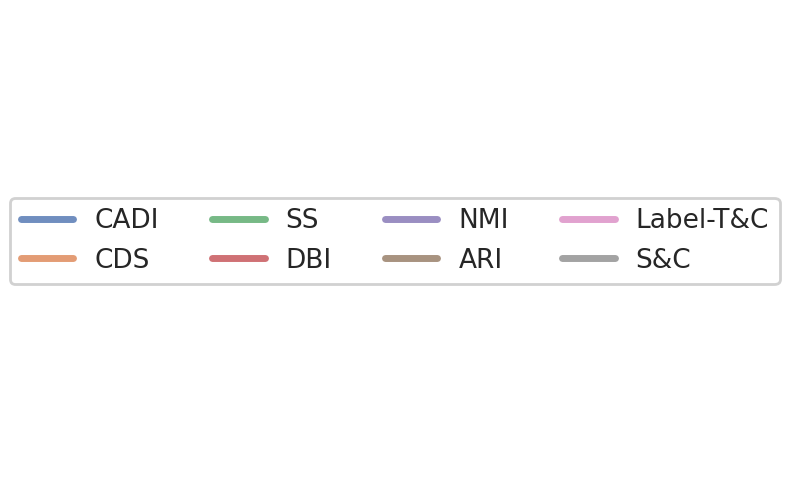

In [ ]:
fig_legend

## Individually

In [ ]:
from project_consts import RESULTS_DIR
import numpy as np
import json

dataset = 'MNIST'
alg = 'TSNE'

time_dir = RESULTS_DIR / f"time_taken_{dataset}_{alg}"
frac_file = f"{dataset}_fracs.npy"
time_file = f"{dataset}_time_taken.json"

fracs = np.load(time_dir / frac_file)
with open(time_dir / time_file) as f:
    data = json.load(f)

In [ ]:
data = data[1]
fracs = fracs[:len(list(data.values())[0])]

In [ ]:
import matplotlib.patheffects as pe
from matplotlib.ticker import ScalarFormatter

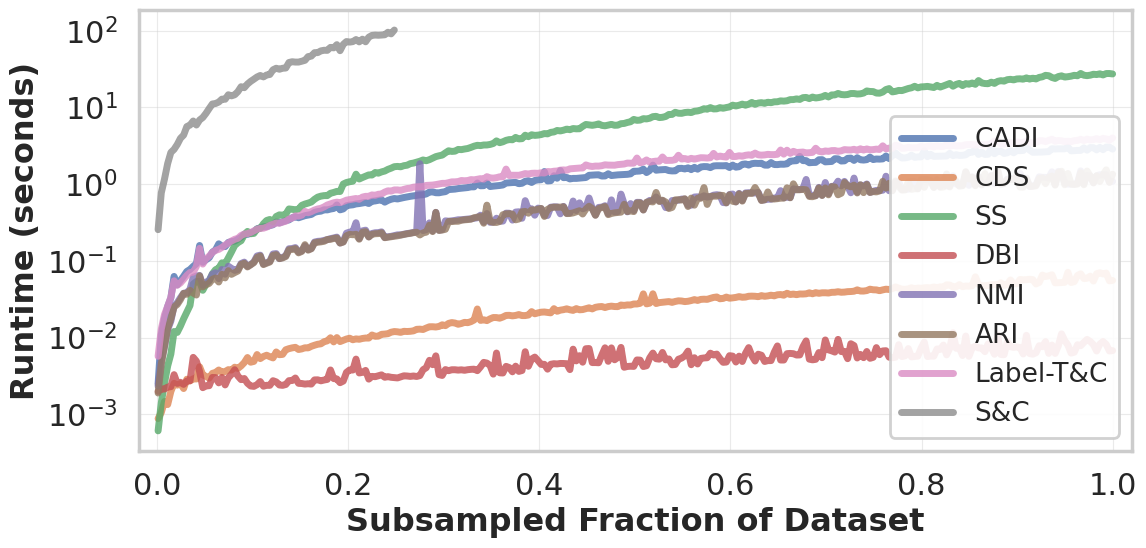

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context('poster')
sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(12, 6))

colors = sns.color_palette('deep', len(data))

# Plot runtime curve with smooth interpolation
for idx, (metric_name, runtimes) in enumerate(data.items()):
    # if metric_name == 'S&C': continue
    if metric_name == 'CADI-100': continue

    runtimes = np.array(runtimes)
    
    # Plot the line with markers
    line, = ax.plot(fracs[:len(runtimes)], runtimes, 
            linewidth=5,
            label=metric_name,
            color=colors[idx],
            alpha=0.8,
            )
    
    # line.set_path_effects([
    #     pe.Stroke(linewidth=5.1, foreground='black', alpha=1),
    #     pe.Normal(),
    # ])

    # line.set_solid_capstyle('round')
    # line.set_solid_joinstyle('round')


# Formatting
ax.set_xlabel('Subsampled Fraction of Dataset', fontsize=23, fontweight='bold')
ax.set_ylabel('Runtime (seconds)', fontsize=23, fontweight='bold')
ax.set_title('', fontsize=18, fontweight='bold')
ax.legend(loc='best', frameon=True, fontsize=19, framealpha=0.9)
ax.grid(True, alpha=0.4, linewidth=0.8)
ax.set_xlim(fracs.min() - 0.02, fracs.max() + 0.02)

ax.set_yscale('log')
   

# Make sure y-axis starts at 0
MAX_Y_AXIS = 10
if np.all([np.all(np.array(times) >= 0) for times in data.values()]):
    ax.set_ylim(
        # bottom=0,
        #  top=MAX_Y_AXIS
    )

plt.tight_layout()
plt.show()

In [ ]:
time_taken = np.array(data['S&C'])

Fitted model: time ≈ 1.215346e+03 * frac^2 + 9.440103e+01 * frac + 5.712440e-01
R^2 = 0.994305


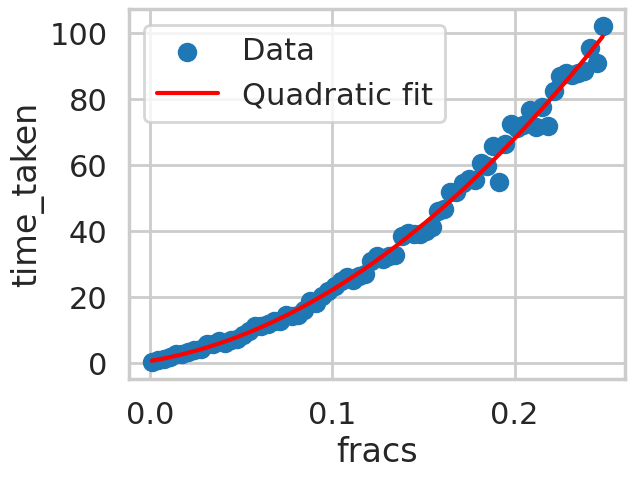

Extrapolated time at frac=1: 1310.318184


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assume fracs and time_taken are 1D numpy arrays

# 1. Fit a quadratic model: time_taken ≈ a*fracs^2 + b*fracs + c
coeffs = np.polyfit(fracs[:len(time_taken)], time_taken, 2)
a, b, c = coeffs

print(f"Fitted model: time ≈ {a:.6e} * frac^2 + {b:.6e} * frac + {c:.6e}")

# 2. Compute fitted values
time_fit = np.polyval(coeffs, fracs[:len(time_taken)])

# 3. Compute R^2 to check goodness of fit
ss_res = np.sum((time_taken - time_fit)**2)
ss_tot = np.sum((time_taken - np.mean(time_taken))**2)
r_squared = 1 - ss_res/ss_tot

print(f"R^2 = {r_squared:.6f}")

# 4. Plot to visually confirm
plt.scatter(fracs[:len(time_taken)], time_taken, label="Data")
plt.plot(fracs[:len(time_taken)], time_fit, color="red", label="Quadratic fit")
plt.xlabel("fracs")
plt.ylabel("time_taken")
plt.legend()
plt.show()

# 5. Extrapolate to frac = frac_extrap
frac_extrap = 1
time_extrap = np.polyval(coeffs, frac_extrap)

print(f"Extrapolated time at frac={frac_extrap}: {time_extrap:.6f}")
